# Base de dades 2020

Aquest notebook utilitza els conjunts de dades del 2020 proporcionats per la competició IPIN. Amb aquests s'ha seguit els següents passos:

1. Anàlisi exploratòria i reducció manual de la dimensionalitat
2. Experiments amb models d'aprenentatge automàtic

In [1]:
# llibreries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
# Detectar si s'executa a Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# A Colab cal clonar el repositori públic per tenir accés a les dades.
# En local s'assumeix que el notebook s'executa des de l'arrel del repositori clonat.
if IN_COLAB:
    if not os.path.isdir('indoor-location'):
        !git clone https://github.com/nuriacanals3/indoor-location.git
    os.chdir('indoor-location')

In [3]:
# Carregar les dades

# Definir la ruta base de les dades
base_path = './Dades/2020/'

# Train
df_train_rss_2020 = pd.read_csv(os.path.join(base_path, 'ipin2020_trainrss.csv'), header=None)
df_train_fl_2020  = pd.read_csv(os.path.join(base_path, 'ipin2020_trainflr.csv'), header=None)

# Validate
df_val_rss_2020 = pd.read_csv(os.path.join(base_path, 'ipin2020_validrss.csv'), header=None)
df_val_fl_2020  = pd.read_csv(os.path.join(base_path, 'ipin2020_validflr.csv'), header=None)

# Test
df_test_rss_2020 = pd.read_csv(os.path.join(base_path, 'ipin2020_ctestreducedrss.csv'), header=None)
df_test_fl_2020  = pd.read_csv(os.path.join(base_path, 'ipin2020_ctestreducedfloor.csv'), header=None)

## Anàlisi exploratòria i reducció manual de la dimensionalitat
A continuació es fa un anàlisi de les dades i una reducció manual de la dimensionalitat del conjunt d'entrenament utilitzant els següents dataframes:
*   df_train_rss_2020
*   df_train_fl_2020



In [4]:
# Dimensionalitat de les dades
df_train_rss_2020.shape

(4002, 468)

In [ ]:
# Anomenar columnes APs
nous_noms = [f"AP_{i}" for i in range(468)]
df_train_rss_2020.columns = nous_noms
df_val_rss_2020.columns = nous_noms
df_test_rss_2020.columns = nous_noms

# Juntar el dataset de potències amb el de planta
df_train_2020 = pd.concat([df_train_rss_2020, df_train_fl_2020], axis=1)

# Reanomenar la columna objectiu
df_train_2020 = df_train_2020.rename(columns={0: 'Pis'})

df_train_2020.head()

,AP_0,AP_1,AP_2,AP_3,AP_4,AP_5,AP_6,AP_7,AP_8,AP_9,...,AP_459,AP_460,AP_461,AP_462,AP_463,AP_464,AP_465,AP_466,AP_467,Pis
0,-59,-60,-81,-81,-82,-82,-82,-82,-82,-83,...,100,100,100,100,100,100,100,100,100,1
1,-62,-63,100,-78,-84,100,-82,-82,-84,-79,...,100,100,100,100,100,100,100,100,100,1
2,-67,-68,100,-80,100,100,-80,-81,100,-80,...,100,100,100,100,100,100,100,100,100,1
3,-66,-66,-84,100,-86,100,-80,-81,100,100,...,100,100,100,100,100,100,100,100,100,1
4,-58,-60,-86,100,100,-89,-83,-82,-77,100,...,100,100,100,100,100,100,100,100,100,1


In [ ]:
# Canviar els valors 100 per a NaN per analitzar les dades
df_train_2020 = df_train_2020.replace(100, np.nan)

In [ ]:
# Rang potències
rss_min_global = df_train_2020.drop(columns=['Pis']).min().min()
rss_max_global = df_train_2020.drop(columns=['Pis']).max().max()

print(f"Senyal més feble global: {rss_min_global} dBm")
print(f"Senyal més forta global: {rss_max_global} dBm")

Senyal més feble global: -99.0 dBm
Senyal més forta global: -40.0 dBm


In [ ]:
# Columna objectiu
plantes = df_train_2020['Pis'].unique()

print(f"L'edifici està composat per {len(plantes)} plantes: {plantes.tolist()}")

L'edifici està composat per 5 plantes: [1, 2, 3, 5, 4]


### Pas 1 - Reducció de la dimensionalitat:

Eliminar els punts d'accés (AP) que no reben cap senyal. En aquest cas s'ha passat d'un conjunt amb 468 punts d'accés a un reduït de 453.

In [ ]:
# Eliminar les columnes on tots els valors siguin NaN
df_train_2020_reduced = df_train_2020.dropna(axis=1, how='all')

print(f"Columnes originals: {df_train_2020.shape[1]}")
print(f"Columnes útils: {df_train_2020_reduced.shape[1]}")

Columnes originals: 469
Columnes útils: 453


### Pas 2 - Reducció de la dimensionalitat:

1. Anàlisi dels punts d'accés (APs) amb molt baixa latència.
2. Anàlisi de la freqüència d'aparició dels punts d'accés per planta.
3. Anàlisi de la freqüència de les potències més fortes.
4. Eliminar els APs amb una detecció menor al 5% de registres i un RSS major a -80.


**1. Anàlisi dels APs amb molt baixa latència:**

In [ ]:
# Comptar quants cops apareix NaN a cada columna
aps = df_train_2020_reduced.drop(columns=['Pis'])
comptador_no_senyal = aps.isna().sum() # Índex = nom columna (AP), Valor = comptador

# Calcular el percentatge d'absència de senyal
percentatge_no_senyal = (comptador_no_senyal / len(aps)) * 100

# Unir les dades per visualitzar-les
df_analisi_buits = pd.DataFrame({
    'Num_No_Senyal': comptador_no_senyal,
    'Percentatge_Buits': percentatge_no_senyal
})

# Ordenar descendentment per percentatge de buits
df_analisi_buits = df_analisi_buits.sort_values(by='Percentatge_Buits', ascending=False)

# Mostrar els 20 primers
print("Top 20 punts d'accés Wi-Fi menys utilitzats:")
print(df_analisi_buits.head(20))

Top 20 punts d'accés Wi-Fi menys utilitzats:
        Num_No_Senyal  Percentatge_Buits
AP_451           4001          99.975012
AP_450           4001          99.975012
AP_425           4001          99.975012
AP_417           4001          99.975012
AP_416           4001          99.975012
AP_385           4001          99.975012
AP_384           4001          99.975012
AP_377           4001          99.975012
AP_371           4001          99.975012
AP_387           4001          99.975012
AP_388           4001          99.975012
AP_401           4001          99.975012
AP_415           4001          99.975012
AP_372           4001          99.975012
AP_97            4001          99.975012
AP_102           4001          99.975012
AP_367           4001          99.975012
AP_448           4001          99.975012
AP_445           4001          99.975012
AP_440           4001          99.975012


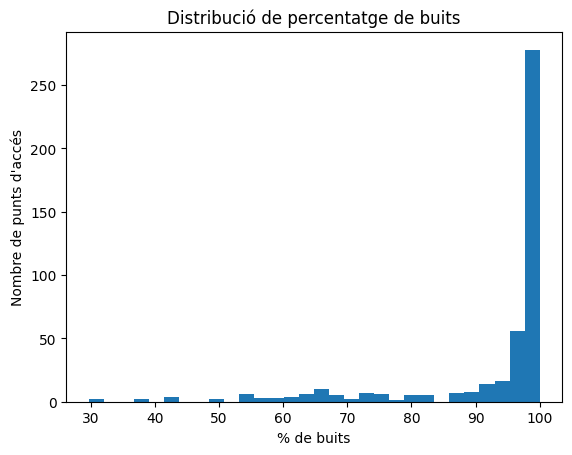

In [ ]:
# Histograma per veure la distribució global
plt.figure()
plt.hist(df_analisi_buits['Percentatge_Buits'], bins=30)
plt.xlabel("% de buits")
plt.ylabel("Nombre de punts d'accés")
plt.title("Distribució de percentatge de buits")
plt.show()


In [ ]:
# Mostrar el total que passen el 95% de buits
punts_mes_95 = df_analisi_buits[df_analisi_buits['Percentatge_Buits'] > 95]
print(f"Punts Wi-Fi amb més del 95% buits: {len(punts_mes_95)} de {aps.shape[1]}")
print(punts_mes_95)

Punts Wi-Fi amb més del 95% buits: 338 de 452
        Num_No_Senyal  Percentatge_Buits
AP_451           4001          99.975012
AP_450           4001          99.975012
AP_425           4001          99.975012
AP_417           4001          99.975012
AP_416           4001          99.975012
...               ...                ...
AP_136           3817          95.377311
AP_105           3813          95.277361
AP_104           3809          95.177411
AP_300           3806          95.102449
AP_93            3803          95.027486

[338 rows x 2 columns]


Aquest anàlisi mostra que existeixen molts punts d'accés on pràcticament tots els seus registres són buits. A continuació s'analitza en profunditat la freqüència de detecció de cada punt d'accés i la potència màxima.

**2. Anàlisi de la freqüència d'aparició dels APs en cada planta:**

Heatmap per veure quantes vegades es detecta cada AP en cada planta.

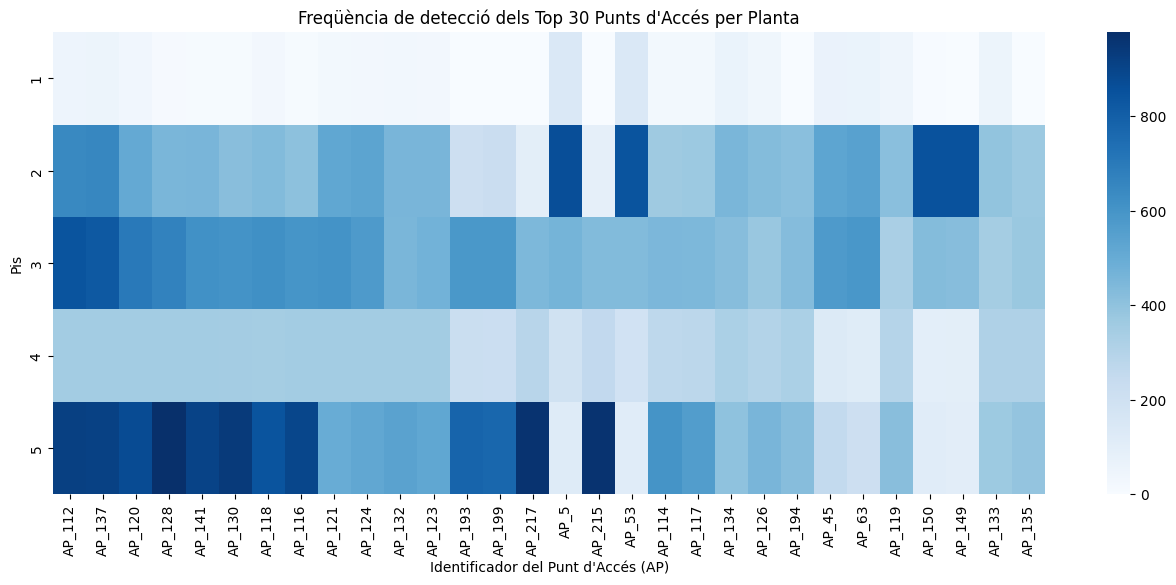

In [ ]:
# Calcular la freqüència: quantes vegades es veu cada AP a cada pis
freq_ap_pis = df_train_2020_reduced.groupby('Pis').count()

# Visualització: filtrar els 30 que més apareixen per veure-ho més clar
top_30_aps = freq_ap_pis.sum().nlargest(30).index

plt.figure(figsize=(16, 6))
sns.heatmap(freq_ap_pis[top_30_aps], cmap='Blues', annot=False)
plt.title('Freqüència de detecció dels Top 30 Punts d\'Accés per Planta')
plt.ylabel('Pis')
plt.xlabel('Identificador del Punt d\'Accés (AP)')
plt.show()



**3. Anàlisi de la freqüència de les potències més fortes:**

Histograma de freqüències dels valors més potents de cada registre de manera global i per planta.

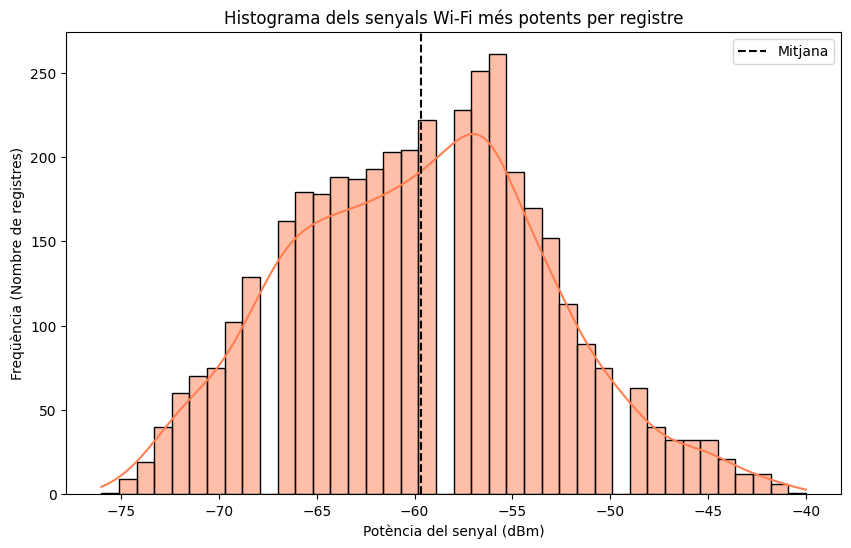

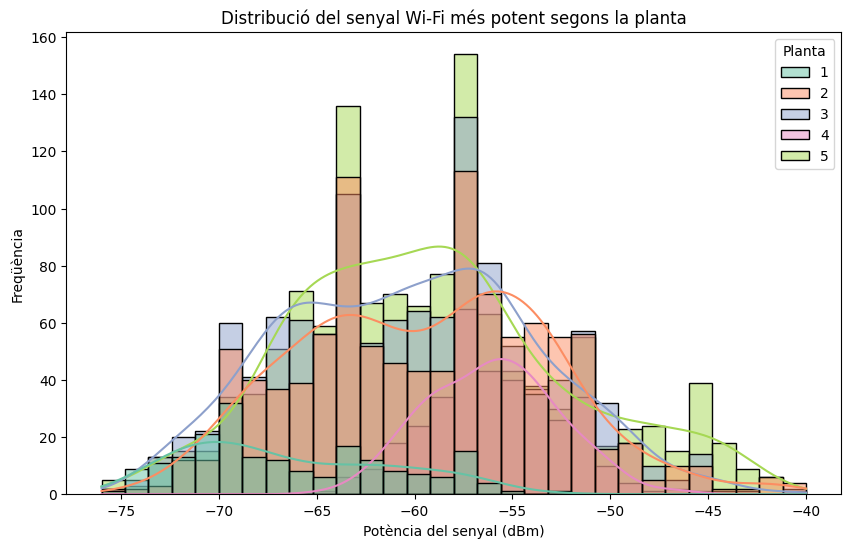

In [ ]:
# Separar la columna objectiu
pisos = df_train_2020_reduced.iloc[:, -1]
senyals = df_train_2020_reduced.iloc[:, :-1]

# Trobar el senyal més potent per a cada registre
valors_mes_potents = senyals.max(axis=1)

# Histograma global
plt.figure(figsize=(10, 6))
sns.histplot(valors_mes_potents, bins=40, color='coral', kde=True)
plt.title('Histograma dels senyals Wi-Fi més potents per registre')
plt.xlabel('Potència del senyal (dBm)')
plt.ylabel('Freqüència (Nombre de registres)')
plt.axvline(valors_mes_potents.mean(), color='black', linestyle='dashed', linewidth=1.5, label='Mitjana')
plt.legend()
plt.show()

# Histograma per pis
df_plot = senyals.copy()
df_plot['Planta'] = pisos
df_plot['max_signal'] = valors_mes_potents

plt.figure(figsize=(10, 6))
sns.histplot(data=df_plot, x='max_signal', hue='Planta', kde=True, bins=30, palette='Set2')
plt.title('Distribució del senyal Wi-Fi més potent segons la planta')
plt.xlabel('Potència del senyal (dBm)')
plt.ylabel('Freqüència')
plt.show()



**4. Eliminar els APs amb una detecció menor al 5% de registres i un RSS major a -80:**

In [ ]:
# Separar variable objectiu
aps = df_train_2020_reduced.iloc[:, :-1]
planta = df_train_2020_reduced.iloc[:, -1]

# Calcular els APs possibles a eliminar
stats_signal = pd.DataFrame({
    "count": aps.count(),
    "max": aps.max()
})

# Llindars
perc_detectats = 0.05
potencia_max = -80

# Identificar els APs a eliminar
aps_eliminar = stats_signal[
    (stats_signal['count'] < len(aps)*perc_detectats) &
    (stats_signal['max'] < potencia_max)
]

# Eliminar i ajuntar la variable planta
aps_reduced  = aps.drop(columns=aps_eliminar.index)
df_train_2020_reduced_2 = pd.concat([aps_reduced, planta], axis=1)

print(f"{len(aps_eliminar)} APs eliminats: {aps_eliminar.index.to_list()} \n {aps_eliminar}")
print(f"Dimensions originals: {df_train_2020_reduced.shape[1]}")
print(f"Dimensions noves: {df_train_2020_reduced_2.shape[1]}")

257 APs eliminats: ['AP_19', 'AP_20', 'AP_23', 'AP_25', 'AP_28', 'AP_30', 'AP_36', 'AP_37', 'AP_38', 'AP_39', 'AP_40', 'AP_41', 'AP_43', 'AP_47', 'AP_48', 'AP_52', 'AP_54', 'AP_55', 'AP_56', 'AP_57', 'AP_64', 'AP_66', 'AP_67', 'AP_70', 'AP_71', 'AP_73', 'AP_74', 'AP_76', 'AP_78', 'AP_80', 'AP_86', 'AP_87', 'AP_90', 'AP_92', 'AP_95', 'AP_97', 'AP_98', 'AP_101', 'AP_102', 'AP_103', 'AP_107', 'AP_110', 'AP_115', 'AP_122', 'AP_125', 'AP_129', 'AP_140', 'AP_143', 'AP_147', 'AP_148', 'AP_152', 'AP_155', 'AP_156', 'AP_157', 'AP_158', 'AP_160', 'AP_161', 'AP_163', 'AP_164', 'AP_165', 'AP_166', 'AP_167', 'AP_168', 'AP_170', 'AP_171', 'AP_172', 'AP_173', 'AP_181', 'AP_183', 'AP_184', 'AP_185', 'AP_186', 'AP_188', 'AP_189', 'AP_190', 'AP_191', 'AP_192', 'AP_195', 'AP_196', 'AP_197', 'AP_198', 'AP_202', 'AP_203', 'AP_224', 'AP_227', 'AP_228', 'AP_230', 'AP_231', 'AP_232', 'AP_233', 'AP_235', 'AP_236', 'AP_237', 'AP_238', 'AP_240', 'AP_241', 'AP_242', 'AP_243', 'AP_244', 'AP_245', 'AP_246', 'AP_247

En aquest pas s'ha eliminat 257 APs, passant de 452 a 195.

### Pas 3 - Reducció de la dimensionalitat:

1. Anàlisi de les correlacions entre APs.
2. Eliminar APs altament correlacionats (Redundància).

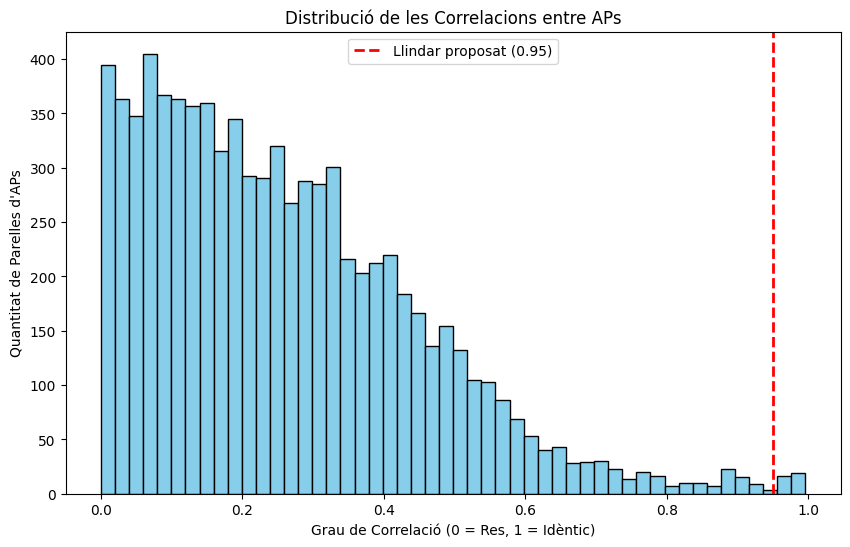

In [ ]:
# Almenys han de tenir 30 mostres compartides per calcular la correlació
minim_mostres_compartides = 30

# Calcular la matriu de correlació
corr_matrix = df_train_2020_reduced_2.drop(columns=['Pis']).corr(min_periods=minim_mostres_compartides).abs()

# Seleccionar el triangle superior de la matriu per evaluar només 1 cop cada parella
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Crear histograma
upper_values = upper.stack()
plt.figure(figsize=(10, 6))
plt.hist(upper_values, bins=50, color='skyblue', edgecolor='black')

# Dibuixar una línia vermella on llindar (0.95)
plt.axvline(x=0.95, color='red', linestyle='--', linewidth=2, label='Llindar proposat (0.95)')

plt.title('Distribució de les Correlacions entre APs')
plt.xlabel('Grau de Correlació (0 = Res, 1 = Idèntic)')
plt.ylabel('Quantitat de Parelles d\'APs')
plt.legend()
plt.show()

La majoria de punts d'accés no estan altament correlacionats, és a dir, aporten informació diferent.

In [ ]:
# Definir llindar (si dos APs s'assemble més d'aquest %, s'elimina un)
llindar = 0.95

# Identificar les columnes a eliminar
to_drop = [column for column in upper.columns if any(upper[column] > llindar)]

print(f"Amb un mínim de {minim_mostres_compartides} mostres, s'han detectat {len(to_drop)} APs altament correlacionats (llindar > {llindar})")

# Veure quins APs s'han eliminat
print("Columnes a eliminar:", to_drop)

Amb un mínim de 30 mostres, s'han detectat 38 APs altament correlacionats (llindar > 0.95)
Columnes a eliminar: ['AP_1', 'AP_4', 'AP_7', 'AP_27', 'AP_31', 'AP_46', 'AP_51', 'AP_53', 'AP_63', 'AP_82', 'AP_120', 'AP_124', 'AP_130', 'AP_132', 'AP_134', 'AP_137', 'AP_141', 'AP_150', 'AP_162', 'AP_176', 'AP_180', 'AP_194', 'AP_199', 'AP_207', 'AP_208', 'AP_212', 'AP_213', 'AP_217', 'AP_219', 'AP_221', 'AP_225', 'AP_307', 'AP_315', 'AP_336', 'AP_359', 'AP_360', 'AP_392', 'AP_393']


In [ ]:
def visualitzar_totes_les_correlacions(df, matriu_upper, llindar):
    """
    Busca els parells altament correlacionats i en dibuixa un gràfic de dispersió.
    """
    # 1. Trobar quins parells superen el llindar
    parells_corr = matriu_upper.stack()
    parells_alts = parells_corr[parells_corr > llindar]

    if len(parells_alts) == 0:
        print(f"No s'ha trobat cap parell amb una correlació superior a {llindar}.")
        return

    print(f"S'han detectat {len(parells_alts)} parells altament correlacionats. Generant gràfiques...\n")
    print("-" * 50)

    # 2. Iterar sobre cada parell i dibuixar-lo
    for (ap_principal, ap_eliminat), valor in parells_alts.items():
        plt.figure(figsize=(6, 4))

        mostres_ap_princ = df[ap_principal].notna().sum()
        mostres_ap_elim = df[ap_eliminat].notna().sum()

        # Calcular quantes vegades s'han vist junts (cap dels dos és NaN)
        mostres_compartides = df[[ap_principal, ap_eliminat]].dropna().shape[0]

        # Dibuixem els punts amb certa transparència (alpha) per veure on s'acumulen
        plt.scatter(df[ap_principal], df[ap_eliminat], alpha=0.3, color='teal')

        # Estil i etiquetes
        plt.title(f"Correlació: {valor:.4f}\n{ap_principal} (Es manté) vs {ap_eliminat} (S'elimina)")
        plt.xlabel(f"Senyal de {ap_principal}")
        plt.ylabel(f"Senyal de {ap_eliminat}")
        plt.grid(True, linestyle='--', alpha=0.6)

        plt.show()


visualitzar_totes_les_correlacions(df_train_2020_reduced_2, upper, llindar)

Output hidden; open in https://colab.research.google.com to view.

En aquests gràfics, es forma una linia recta ascendent la qual mostra la correlació dels dos punts d'accés. Els dos tenen intensitats similars i creixen i decreixen en els mateixos registres.

In [ ]:
# Eliminar aquests APs redundants
df_train_2020_reduced_3 = df_train_2020_reduced_2.drop(columns=to_drop)

print(f"Dimensions originals: {df_train_2020_reduced_2.shape[1]}")
print(f"Dimensions noves: {df_train_2020_reduced_3.shape[1]}")

Dimensions originals: 196
Dimensions noves: 158


### Pas 4 - Reducció de la dimensionalitat:

1. Anàlitzar la variabilitat i potència dels punts d'accés restants.
2. Eliminar els punts d'accés amb baixa variabilitat i potència.


In [ ]:
# Analisi per AP
min_max = df_train_2020_reduced_3.drop(columns='Pis').describe().loc[['min', 'max']]

print("\nSenyal més feble i més forta per AP:")
print(min_max)


Senyal més feble i més forta per AP:
     AP_0  AP_2  AP_3  AP_5  AP_6  AP_8  AP_9  AP_10  AP_11  AP_12  ...  \
min -94.0 -94.0 -94.0 -94.0 -94.0 -95.0 -94.0  -93.0  -93.0  -93.0  ...   
max -53.0 -45.0 -68.0 -46.0 -40.0 -77.0 -68.0  -77.0  -77.0  -76.0  ...   

     AP_334  AP_346  AP_361  AP_362  AP_363  AP_365  AP_379  AP_382  AP_419  \
min   -94.0   -92.0   -96.0   -93.0   -93.0   -94.0   -91.0   -94.0   -92.0   
max   -66.0   -78.0   -66.0   -67.0   -69.0   -78.0   -52.0   -49.0   -80.0   

     AP_420  
min   -95.0  
max   -72.0  

[2 rows x 157 columns]


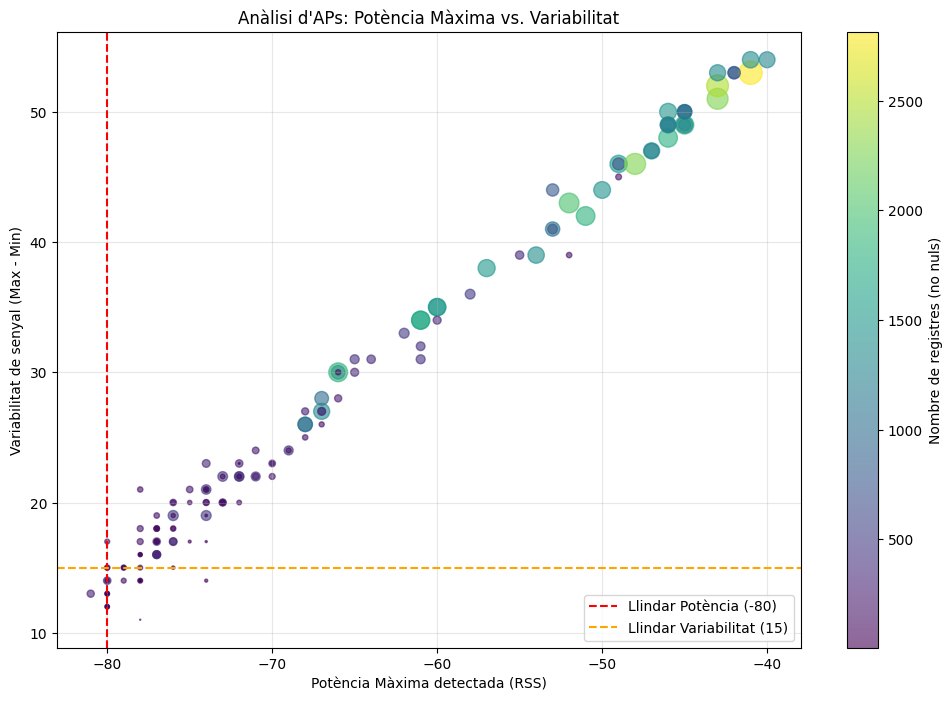

In [ ]:
# Transposar per tenir els APs a les files
df_filtre = min_max.T

# Calcular el rang (max - min)
df_filtre['rang'] = df_filtre['max'] - df_filtre['min']

# Comptar quants valors no són nulls per AP
df_filtre['comptador_non_null'] = df_train_2020_reduced_3.drop(columns='Pis').count()

# Definir els llindars
llindar_potencia_max = -80
llindar_rang = 15

# Gràfic
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_filtre['max'],
    df_filtre['rang'],
    c=df_filtre['comptador_non_null'],
    cmap='viridis',
    alpha=0.6,
    s=df_filtre['comptador_non_null'] / 10
)

# Afegir els llindars
plt.axvline(x=llindar_potencia_max, color='red', linestyle='--', label='Llindar Potència (-80)')
plt.axhline(y=llindar_rang, color='orange', linestyle='--', label='Llindar Variabilitat (15)')

plt.colorbar(scatter, label='Nombre de registres (no nuls)')
plt.title('Anàlisi d\'APs: Potència Màxima vs. Variabilitat')
plt.xlabel('Potència Màxima detectada (RSS)')
plt.ylabel('Variabilitat de senyal (Max - Min)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


*   **Quadrant Superior Dret:** APs amb senyal fort i molta variabilitat. Són els millors predictors.

*   **Zona Esquerra:** APs que tenen una potència màxima molt baixa. Solen ser punts de plantes llunyanes o altres edificis.

*   **Zona Inferior:** APs que tenen una baixa variabilitat. Si tenen pocs registres, són prescindibles.

*   **Color/Mida:** Com més groc i gran sigui el punt, més dades té aquell AP. Si un AP està situat a la zona "dolenta" i té molt pocs registres, és prescindible.

In [ ]:
# Aplicar el filtre
aps_bons = df_filtre[
    (df_filtre['rang'] >= llindar_rang) &
    (df_filtre['max'] > llindar_potencia_max)
].index

# Crear el DataFrame filtrat
df_train_2020_reduced_4 = df_train_2020_reduced_3[aps_bons.tolist() + ['Pis']]

print(f"Dimensions originals: {df_train_2020_reduced_3.shape[1]}")
print(f"Dimensions noves: {df_train_2020_reduced_4.shape[1]}")

Dimensions originals: 158
Dimensions noves: 130


## Experiments

A continuació, s'han elaborat una sèrie d'experiments utilitzant els models Random Forest i KNN.

### Experiment 1:

Utilitzar les dades sense tractar en el RF i KNN.

In [ ]:
# Preparar les dades
X_train = df_train_rss_2020.fillna(-105)
y_train = df_train_fl_2020.values.ravel()

X_val = df_val_rss_2020.fillna(-105)
y_val = df_val_fl_2020.values.ravel()

In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {len(X_train.columns)}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 468
Accuracy a Validació: 0.9847

Informe de Classificació:
              precision    recall  f1-score   support

           1     1.0000    0.9493    0.9740       138
           2     0.9614    1.0000    0.9803       199
           3     0.9833    0.9752    0.9793       121
           4     0.9900    1.0000    0.9950        99
           5     1.0000    0.9938    0.9969       160

    accuracy                         0.9847       717
   macro avg     0.9869    0.9836    0.9851       717
weighted avg     0.9851    0.9847    0.9846       717



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=9,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 468
Accuracy a Validació: 0.9358

Informe de Classificació:
              precision    recall  f1-score   support

           1     1.0000    0.8551    0.9219       138
           2     0.9171    1.0000    0.9567       199
           3     0.9836    0.9917    0.9877       121
           4     1.0000    0.7475    0.8555        99
           5     0.8602    1.0000    0.9249       160

    accuracy                         0.9358       717
   macro avg     0.9522    0.9189    0.9293       717
weighted avg     0.9430    0.9358    0.9341       717



### Experiment 2:
Conjunt reduït amb la reducció manual inicial.

In [ ]:
# Preparar les dades
columnes_finals = df_train_2020_reduced_4.drop(columns=['Pis']).columns.tolist()

X_train = df_train_rss_2020[columnes_finals].fillna(-105)
y_train = df_train_fl_2020.values.ravel()

X_val = df_val_rss_2020[columnes_finals].fillna(-105)
y_val = df_val_fl_2020.values.ravel()

In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 129
Accuracy a Validació: 0.9847

Informe de Classificació:
              precision    recall  f1-score   support

           1     1.0000    0.9493    0.9740       138
           2     0.9803    1.0000    0.9900       199
           3     0.9675    0.9835    0.9754       121
           4     0.9802    1.0000    0.9900        99
           5     0.9937    0.9875    0.9906       160

    accuracy                         0.9847       717
   macro avg     0.9843    0.9840    0.9840       717
weighted avg     0.9849    0.9847    0.9846       717



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 129
Accuracy a Validació: 0.9289

Informe de Classificació:
              precision    recall  f1-score   support

           1     1.0000    0.9058    0.9506       138
           2     0.9502    0.9598    0.9550       199
           3     0.9302    0.9917    0.9600       121
           4     0.9157    0.7677    0.8352        99
           5     0.8603    0.9625    0.9086       160

    accuracy                         0.9289       717
   macro avg     0.9313    0.9175    0.9219       717
weighted avg     0.9316    0.9289    0.9281       717



### Experiment 3:
Aplicar una reducció de dimensionalitat més agresiva.

In [ ]:
def aplicar_reduccio_agressiva(df, ap_cols, floor_col='Pis',
                               min_presencia=0.05,
                               min_variance=15.0,
                               top_n_per_floor=10,
                               quantile=0.75,
                               valor_nan=-105):
    """
    Aplica filtres de reducció de dimensionalitat per optimitzar el dataset d'APs.

    Paràmetres:
    - df: DataFrame original (NaN = AP no detectat).
    - ap_cols: Llista de columnes que són punts d'accés.
    - floor_col: Nom de la columna que indica la planta.
    - min_presencia: % mínim de registres on l'AP ha d'haver estat detectat (0.0 a 1.0).
    - min_variance: Llindar de variància.
    - top_n_per_floor: Número d'APs per cada planta.
    - quantile: Percentil per avaluar la representativitat de cada AP per planta (0.0 a 1.0).
    - valor_nan: Valor per substituir els NaN al DataFrame retornat.
    """

    print(f"--- Iniciant reducció: {len(ap_cols)} APs inicials ---")
    df_temp = df.copy()
    aps_actuals = list(ap_cols)

    # 1. FILTRE DE PRESÈNCIA
    # % de vegades que cada AP apareix
    presencia = df_temp[aps_actuals].notna().mean()
    # Aplicar filtre
    aps_actuals = presencia[presencia >= min_presencia].index.tolist()
    print(f"Pas 1 (Presència >= {min_presencia*100}%): Queden {len(aps_actuals)} APs")

    # 2. FILTRE DE VARIÀNCIA
    # Omplir NaN amb valor_nan per poder calcular la variància
    df_filled = df_temp[aps_actuals].fillna(valor_nan)
    # Elimina els AP amb poca variabilitat
    selector = VarianceThreshold(threshold=min_variance)
    selector.fit(df_filled)
    aps_actuals = [ap for ap, support in zip(aps_actuals, selector.get_support()) if support]
    print(f"Pas 2 (Variància >= {min_variance}): Queden {len(aps_actuals)} APs")

    # 3. FILTRE DE COBERTURA DE PLANTA
    millors_aps_per_planta = set()
    for planta in df_temp[floor_col].unique():
      # Agafar les dades de la planta
      df_planta = df_temp[df_temp[floor_col] == planta][aps_actuals]
      # Calcular el percentil per trobar les deteccions representatives
      representativitat = df_planta.quantile(quantile)
      # Eliminar APs que mai detectats en la planta
      representativitat = representativitat.dropna()
      # Agafar els més representatius
      n = min(top_n_per_floor, len(representativitat))
      top_aps = representativitat.nlargest(n).index.tolist()
      # Combinar els millors APs de les plantes
      millors_aps_per_planta.update(top_aps)

    aps_finals = list(millors_aps_per_planta)
    print(f"Pas 3 (Top {top_n_per_floor} APs per planta, percentil {quantile}): Queden {len(aps_finals)} APs totals")

    # Retornar el DataFrame amb les columnes seleccionades + llista dels APs seleccionats
    cols_no_ap = [c for c in df.columns if c not in ap_cols]
    df_resultat = df[cols_no_ap + aps_finals].copy()
    df_resultat[aps_finals] = df_resultat[aps_finals].fillna(valor_nan)

    return df_resultat, aps_finals

#### Experiment 3.1:

Reducció Moderada

In [ ]:
# Preparació de les dades
df_cons, aps_cons = aplicar_reduccio_agressiva(df_train_2020_reduced_4,
                                               df_train_2020_reduced_4.drop(columns=['Pis']).columns.tolist(),
                                               min_presencia=0.05,
                                               min_variance=15,
                                               top_n_per_floor=50)

X_train = df_train_rss_2020[aps_cons].fillna(-105)
y_train = df_train_fl_2020.values.ravel()

X_val = df_val_rss_2020[aps_cons].fillna(-105)
y_val = df_val_fl_2020.values.ravel()

--- Iniciant reducció: 129 APs inicials ---
Pas 1 (Presència >= 5.0%): Queden 76 APs
Pas 2 (Variància >= 15): Queden 76 APs
Pas 3 (Top 50 APs per planta, percentil 0.75): Queden 76 APs totals


In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 76
Accuracy a Validació: 0.9791

Informe de Classificació:
              precision    recall  f1-score   support

           1     1.0000    0.9493    0.9740       138
           2     0.9707    1.0000    0.9851       199
           3     0.9669    0.9669    0.9669       121
           4     0.9612    1.0000    0.9802        99
           5     0.9936    0.9750    0.9842       160

    accuracy                         0.9791       717
   macro avg     0.9785    0.9782    0.9781       717
weighted avg     0.9795    0.9791    0.9790       717



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=10,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 76
Accuracy a Validació: 0.9442

Informe de Classificació:
              precision    recall  f1-score   support

           1     0.9926    0.9710    0.9817       138
           2     0.9898    0.9799    0.9848       199
           3     0.9593    0.9752    0.9672       121
           4     0.9070    0.7879    0.8432        99
           5     0.8636    0.9500    0.9048       160

    accuracy                         0.9442       717
   macro avg     0.9425    0.9328    0.9364       717
weighted avg     0.9456    0.9442    0.9438       717



#### Experiment 3.2:

Reducció Agresiva

In [ ]:
# Preparació de les dades
df_cons, aps_cons = aplicar_reduccio_agressiva(df_train_2020_reduced_4,
                                               df_train_2020_reduced_4.drop(columns=['Pis']).columns.tolist(),
                                               min_presencia=0.20,
                                               min_variance=20,
                                               top_n_per_floor=20)

X_train = df_train_rss_2020[aps_cons].fillna(-105)
y_train = df_train_fl_2020.values.ravel()

X_val = df_val_rss_2020[aps_cons].fillna(-105)
y_val = df_val_fl_2020.values.ravel()

--- Iniciant reducció: 129 APs inicials ---
Pas 1 (Presència >= 20.0%): Queden 37 APs
Pas 2 (Variància >= 20): Queden 37 APs
Pas 3 (Top 20 APs per planta, percentil 0.75): Queden 37 APs totals


In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 37
Accuracy a Validació: 0.9679

Informe de Classificació:
              precision    recall  f1-score   support

           1     1.0000    0.9203    0.9585       138
           2     0.9522    1.0000    0.9755       199
           3     0.9746    0.9504    0.9623       121
           4     0.9515    0.9899    0.9703        99
           5     0.9688    0.9688    0.9688       160

    accuracy                         0.9679       717
   macro avg     0.9694    0.9659    0.9671       717
weighted avg     0.9688    0.9679    0.9678       717



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=11,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 37
Accuracy a Validació: 0.9135

Informe de Classificació:
              precision    recall  f1-score   support

           1     0.9922    0.9275    0.9588       138
           2     0.9565    0.9950    0.9754       199
           3     0.9664    0.9504    0.9583       121
           4     0.9219    0.5960    0.7239        99
           5     0.7828    0.9688    0.8659       160

    accuracy                         0.9135       717
   macro avg     0.9240    0.8875    0.8965       717
weighted avg     0.9215    0.9135    0.9102       717



### Experiment 4:

A partir del Random Forest del primer experiment, analitzar els punts d'accés més importants que el model determina.

El RF té la propietat feature_importances_ que diu quins APs considera que són més importants.

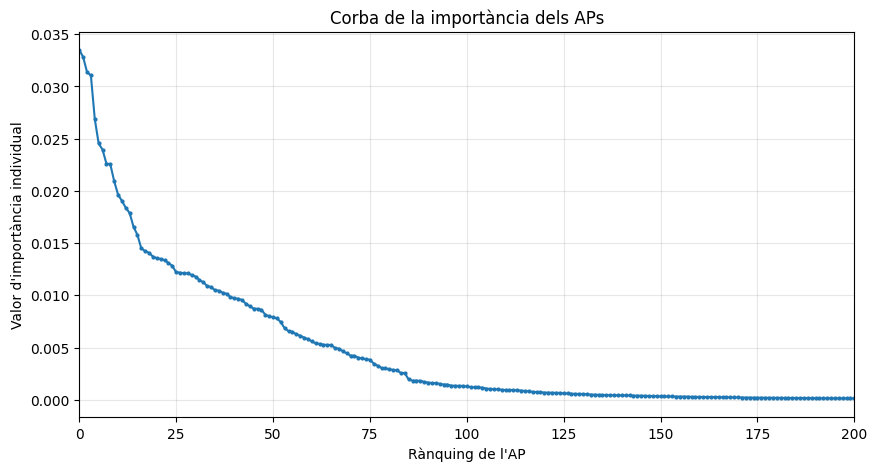

In [ ]:
# APs més importants
importances = model_rf.feature_importances_
noms_columnes = X_train.columns

# Crear un rànquing
importances_df = pd.DataFrame({'AP': noms_columnes, 'Importancia': importances})
data_sorted = importances_df.sort_values(by='Importancia', ascending=False)

# Visualitzar
plt.figure(figsize=(10, 5))
plt.plot(data_sorted['Importancia'].values, marker='o', markersize=2, linestyle='-')
plt.title('Corba de la importància dels APs')
plt.xlabel('Rànquing de l\'AP')
plt.ylabel('Valor d\'importància individual')
plt.grid(True, alpha=0.3)
plt.xlim(0, 200)
plt.show()

In [ ]:
# Preparació de les dades amb els millors APs trobats per RF
n_aps = 80
millors_aps = data_sorted.head(n_aps)['AP'].tolist()
X_train_top = X_train[millors_aps]
X_val_top = X_val[millors_aps]

In [ ]:
# Random Forest
model_rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_final.fit(X_train_top, y_train)

# Validar
preds = model_rf_final.predict(X_val_top)

# Avaluació resultats
print(f"Nombre d'APs utilitzats: {X_train_top.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds, digits=4))

Nombre d'APs utilitzats: 80
Accuracy a Validació: 0.9874

Informe de Classificació:
              precision    recall  f1-score   support

           1     1.0000    0.9493    0.9740       138
           2     0.9803    1.0000    0.9900       199
           3     0.9756    0.9917    0.9836       121
           4     0.9900    1.0000    0.9950        99
           5     0.9938    0.9938    0.9938       160

    accuracy                         0.9874       717
   macro avg     0.9879    0.9870    0.9873       717
weighted avg     0.9876    0.9874    0.9874       717



### Avaluació final

Utilitzant Random Forest de l'experiment 4 amb 80 APs.

In [ ]:
# Preparació de les dades
X_test = df_test_rss_2020[millors_aps].fillna(-105)
y_test = df_test_fl_2020.iloc[:, 4].values

preds_test = model_rf_final.predict(X_test)
print(f"Accuracy a Test: {accuracy_score(y_test, preds_test):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_test, preds_test, digits=4))

Accuracy a Test: 0.9756

Informe de Classificació:
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000         6
           2     1.0000    1.0000    1.0000        15
           3     0.9697    1.0000    0.9846        32
           4     1.0000    0.8000    0.8889        10
           5     0.9500    1.0000    0.9744        19

    accuracy                         0.9756        82
   macro avg     0.9839    0.9600    0.9696        82
weighted avg     0.9766    0.9756    0.9745        82

